# ДЗ №2. Отбор кандидатов


Общая информация
Дата выдачи: 3 февраля 2026

Дедлайн: 23 февраля 2026 23:59 MSK


В этом и последующих домашних заданиях мы построим приближенную к реальной рекомендательную систему. Работать будем с данными marketplace из [T-ECD](https://huggingface.co/datasets/t-tech/T-ECD).

Обычно рекомендательная система состоит из нескольких этапов:
1. Отбор кандидатов (Retrieval)
2. Ранжирование (Ranking)
3. Бизнес-логика (например, условие на то, чтобы товары от одного продавца не стояли в ленте друг за другом)

В этом домашнем задании сосредоточимся на первом этапе.

По ресурсам: at worst нужно 15GB RAM и 3.5GB свободного дискового пространства, GPU не требуется (но можно, если хочется). Дз спокойно запускается на ресурсах Kaggle-а.

In [ ]:
!pip install -q polars huggingface_hub implicit faiss-cpu torch

In [1]:
import glob
import os
import random
import time
import gc
from abc import ABC, abstractmethod
from collections import defaultdict, deque
from math import log2

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
import torch.optim as optim
from implicit.als import AlternatingLeastSquares
from implicit.ann.faiss import FaissModel
from IPython.display import HTML
from scipy.sparse import coo_matrix, csr_matrix
from torch.utils.data import DataLoader, Dataset, IterableDataset
from tqdm.notebook import tqdm
from pathlib import Path
from collections import Counter
from itertools import product

## Download Data

Данные занимают около 3.5 GB

In [ ]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id = "t-tech/T-ECD",
    repo_type = "dataset",
    local_dir = ".",
    local_dir_use_symlinks = False,
    allow_patterns = ["dataset/small/users.pq", "dataset/small/marketplace/**"]
)

## EDA (1p)

Изучите данные (users, items, events). Для работы используйте polars - это более оптимизированный аналог pandas. Обратите внимание, что в polars существуют eager и lazy методы работы с таблицами, и зачастую эффективнее использовать lazy.

1. Оцените количество строк и столбцов в таблицах
2. Для всех категориальных переменных рассчитайте частотность каждого признака и процент null-ов. Удобно вывести результат в виде таблицы с помощью следующего кода: `HTML(polars_df.to_pandas().to_html())` - так не нужно будет задумываться про `display.max_rows`
3. Постройте гистограмму для числовых переменных, также оцените процент null-ов
4. Постройте график, по оси X которого будет отмечен номер файла events (в порядке возрастания), а по оси Y количество уникальных пользователей и айтемов за этот день
5. Постройте график, по оси X которого будет отмечен номер файла events (в порядке возрастания), а по оси Y количество событий в разбивке по `action_type`
6. Кликаутят (переходят на сайт партнера) ли люди один и тот же товар несколько раз?
7. Опционально любая другая аналитика на ваше усмотрение (например, можно покластеризовать эмбеддинги товаров и сравнить пересечения кластеров с категориями)

In [2]:
# uppercase для global переменных, чтобы легче видеть их в коде
USERS = pl.read_parquet("dataset/small/users.pq")
ITEMS = pl.read_parquet("dataset/small/marketplace/items.pq")
CATALOG_SIZE = len(ITEMS)

In [3]:
events_dir = Path("dataset/small/marketplace/events")
event_files = sorted(events_dir.glob("*.pq"))
EVENTS = pl.read_parquet(event_files)

In [4]:
def cat_stats(df):
    cat_cols = [col for col, dtype in df.schema.items() if dtype in (pl.Utf8, pl.String)]
    stats = []
    for col in cat_cols:
        null_pct = df[col].null_count() / len(df) * 100
        freq = df[col].value_counts().head(5)
        stats.append({"column": col, "null_percent": f"{null_pct:.2f}%", "top_values": freq.to_dict(as_series = False)})
    return pl.DataFrame(stats)

In [5]:
def num_stats(df, name):
    print(f"\n{name} числовые:")
    num_cols = [col for col, dtype in df.schema.items() if dtype in (pl.Int64, pl.Int32, pl.Float64, pl.Float32)]
    for col in num_cols:
        null_pct = df[col].null_count() / len(df) * 100
        print(f"{col}: nulls = {null_pct:.2f}%")
        plt.figure()
        plt.hist(df[col].drop_nulls(), bins = 50)
        plt.title(f"{name} - {col}")
        plt.show()

### Users

In [6]:
USERS.shape

(3500000, 3)

In [7]:
HTML(cat_stats(USERS).to_pandas().to_html())

""


In [8]:
num_stats(USERS, "USERS")


USERS числовые:


### Items

In [9]:
ITEMS.shape

(2325409, 6)

In [10]:
HTML(cat_stats(ITEMS).to_pandas().to_html())

,column,null_percent,top_values
0,item_id,0.00%,"{'item_id': ['nfmcg_28419589', 'nfmcg_15230779', 'nfmcg_23968507', 'nfmcg_3004534', 'nfmcg_19847719'], 'count': [1, 1, 1, 1, 1], 'category': None, 'subcategory': None}"
1,category,41.56%,"{'item_id': None, 'count': [4086, 8310, 13292, 8464, 167811], 'category': ['Pet Supplies: Food, Accessories, and Grooming Products', 'Cleaning Supplies and Everyday Household Items', 'Hobby, Creative, and Leisure Products', 'Pharmaceuticals and Medical Supplies', 'Fashion Accessories, Tech Add-ons, and Style Enhancements'], 'subcategory': None}"
2,subcategory,53.02%,"{'item_id': None, 'count': [62212, 6, 5856, 2407, 348], 'category': None, 'subcategory': ['Women's Footwear', 'Farm Produce', 'Office and Computer Zone Furniture', 'Bicycles and Cycling Accessories', 'Culinary Additives and Seasonings']}"



ITEMS числовые:
price: nulls = 0.12%


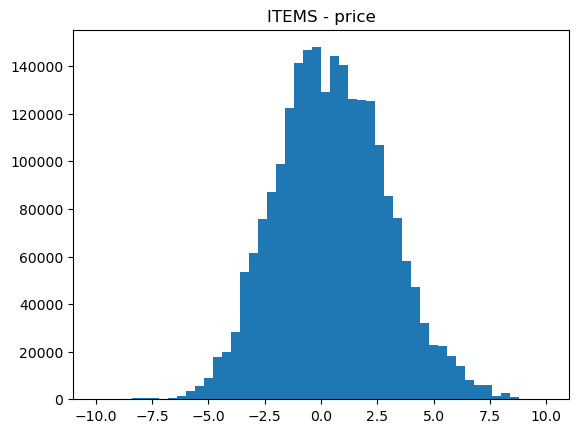

In [11]:
num_stats(ITEMS, "ITEMS")

### Events

In [12]:
EVENTS.shape

(130447117, 6)

In [13]:
HTML(cat_stats(EVENTS).to_pandas().to_html())

,column,null_percent,top_values
0,item_id,0.00%,"{'item_id': ['nfmcg_14279064', 'nfmcg_26472639', 'nfmcg_5257931', 'nfmcg_21250827', 'nfmcg_17383602'], 'count': [5, 1, 1, 1, 3], 'subdomain': None, 'action_type': None, 'os': None}"
1,subdomain,0.03%,"{'item_id': None, 'count': [16115170, 41792, 15741950, 79321588, 8768930], 'subdomain': ['other', None, 'catalog', 'u2i', 'i2i'], 'action_type': None, 'os': None}"
2,action_type,0.00%,"{'item_id': None, 'count': [41792, 126147783, 485448, 3772094], 'subdomain': None, 'action_type': ['like', 'view', 'clickout', 'click'], 'os': None}"
3,os,0.00%,"{'item_id': None, 'count': [94889964, 9788020, 25769133], 'subdomain': None, 'action_type': None, 'os': ['android', 'other', 'ios']}"


In [14]:
num_stats(EVENTS, "EVENTS")


EVENTS числовые:


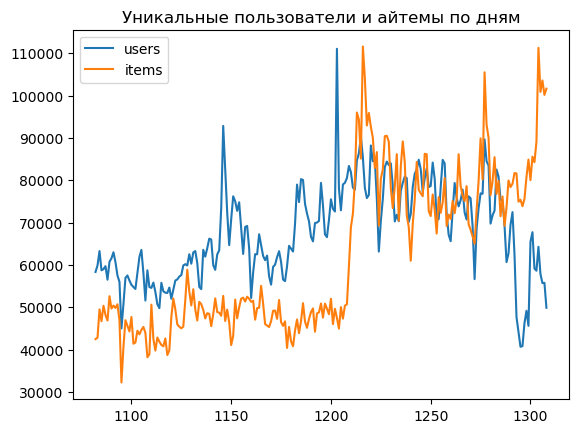

In [15]:
daily = []
for f in event_files:
    day = int(f.stem)
    df = pl.read_parquet(f)
    daily.append({"day": day, "users": df["user_id"].n_unique(), "items": df["item_id"].n_unique()})

daily_df = pl.DataFrame(daily).sort("day")
plt.figure()
plt.plot(daily_df["day"], daily_df["users"], label = "users")
plt.plot(daily_df["day"], daily_df["items"], label = "items")
plt.legend()
plt.title("Уникальные пользователи и айтемы по дням")
plt.show()

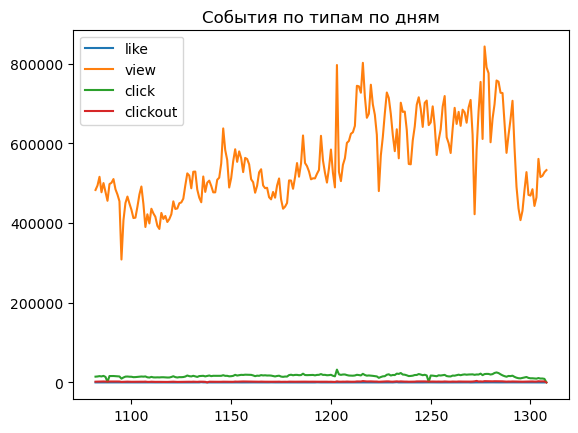

In [16]:
action_daily = {}
for f in event_files:
    day = int(f.stem)
    df = pl.read_parquet(f).group_by("action_type").len()
    for row in df.iter_rows():
        action_daily.setdefault(row[0], []).append({"day": day, "count": row[1]})

plt.figure()
for action, data in action_daily.items():
    df = pl.DataFrame(data).sort("day")
    plt.plot(df["day"], df["count"], label = action)
plt.legend()
plt.title("События по типам по дням")
plt.show()

In [17]:
clicks = EVENTS.filter(pl.col("action_type") == "click")
pairs = clicks.group_by(["user_id", "item_id"]).len()
multi = pairs.filter(pl.col("len") > 1).shape[0]
print(f"Повторные клики: {multi} пар ({multi / len(pairs) * 100:.1f}% от всех пар с кликами)")


Повторные клики: 241107 пар (7.0% от всех пар с кликами)


## Data Splitting (1p)

Прежде чем обучать какие-либо модели, разобъем данные на train-val-test по временной отметке (темпоральный сплит).

На практике обычно используется следующий подход: сначала модель обучается на train части, на val подбирается лучший набор гиперпараметров. Потом модель обучается на train+val, и финальные метрики замеряются на test.

Допишите функцию так, чтобы:

* в train вошли данные start_day < day <= start_day + n_train_days
* в val вошли данные start_day + n_train_days < day <= start_day + n_train_days + n_val_days
* в test вошли данные start_day + n_train_days + n_val_days < day <= start_day + n_train_days + n_val_days + n_test_days

Где start_day - это номер файла, задающий дату, с которой начинается временной промежуток.

Не будем учитывать повторные взаимодействия в обучающих данных. То есть для каждой пары (пользователь, айтем) в train/train_val необходимо оставить только максимальный лейбл.

Ожидаемую результирующую схему данных можно найти ниже. В val и test нужно оставить только позитивы.

In [18]:
def get_data(
    start_day: int = 1250,
    n_train_days: int = 20,
    n_val_days: int = 3,
    n_test_days: int = 5,
    n_users_to_keep: int = 10_000,
    n_items_to_keep: int = 30_000,
) -> tuple[pl.LazyFrame, pl.LazyFrame, pl.LazyFrame, pl.LazyFrame]:

    events = (
        pl.scan_parquet("dataset/small/marketplace/events/")
        .with_columns(
            label=(
                pl.when(pl.col("action_type") == "view")
                .then(0)
                .otherwise(1)
            )  # `label` равен 1, если `action_type` НЕ равен просмотру, и 0 иначе
        )
        .filter(
            (pl.col("timestamp").dt.total_days() > start_day) &
            (pl.col("timestamp").dt.total_days() <= start_day + n_train_days + n_val_days + n_test_days)
        )
        .sort("timestamp")
        .select("timestamp", "user_id", "item_id", "label")
    )

    # Отфильтруем топ-`n_users_to_keep` пользователей и топ-`n_items_to_keep` айтемов по количеству положительных взаимодействий
    # Это нужно, чтобы не обучать модели на слишком больших матрицах (потому что у нас тут всё-таки дз, а не полноценный продовый сетап)
    
    user_positive_counts = (
        events
        .group_by("user_id")
        .agg(pl.col("label").sum())
        .sort("label", descending = True)
        .head(n_users_to_keep)
        .select("user_id")
    )
    
    item_counts = (
        events
        .group_by("item_id")
        .agg(pl.col("label").sum())
        .sort("label", descending = True)
        .head(n_items_to_keep)
        .select("item_id")
    )

    # Кстати, у такого способа фильтрации точно есть проблемы - как минимум то, что что статистика для айтемов считается и по тем юзерам, 
    # которые не попали в топ-`n_users_to_keep`. Но в качестве приближения работает вполне неплохо 
    
    events_filtered = (
        events
        .join(user_positive_counts, on = "user_id", how = "inner")
        .join(item_counts, on = "item_id", how = "inner")
        .collect()
        .lazy()
    )

    train_events = (
        events_filtered
        .filter(
            (pl.col("timestamp").dt.total_days() > start_day) &
            (pl.col("timestamp").dt.total_days() <= start_day + n_train_days)
        )
        .unique(subset = ["user_id", "item_id"], keep = "last")
        .select("user_id", "item_id", "timestamp", "label")
        .cast({"user_id": pl.UInt64, "item_id": pl.String})
    )

    val_events = (
        events_filtered
        .filter(
            (pl.col("timestamp").dt.total_days() > start_day + n_train_days) &
            (pl.col("timestamp").dt.total_days() <= start_day + n_train_days + n_val_days)
        )
        .filter(pl.col("label") == 1)
        .group_by("user_id")
        .agg(pl.col("item_id"))
        .cast({"user_id": pl.UInt64})
    )

    train_val_events = (
        events_filtered
        .filter(
            (pl.col("timestamp").dt.total_days() > start_day) &
            (pl.col("timestamp").dt.total_days() <= start_day + n_train_days + n_val_days)
        )
        .unique(subset = ["user_id", "item_id"], keep = "last")
        .select("user_id", "item_id", "timestamp", "label")
        .cast({"user_id": pl.UInt64, "item_id": pl.String})
    )

    test_events = (
        events_filtered
        .filter(
            (pl.col("timestamp").dt.total_days() > start_day + n_train_days + n_val_days) &
            (pl.col("timestamp").dt.total_days() <= start_day + n_train_days + n_val_days + n_test_days)
        )
        .filter(pl.col("label") == 1)
        .group_by("user_id")
        .agg(pl.col("item_id"))
        .cast({"user_id": pl.UInt64})
    )
    
    return (
        train_events, 
        val_events, 
        train_val_events, 
        test_events
    )

train_events, val_events, train_val_events, test_events = get_data()

train_events = train_events.collect()
val_events = val_events.collect()
train_val_events = train_val_events.collect()
test_events = test_events.collect()

In [19]:
expected_train_schema = pl.Schema({
    "user_id": pl.UInt64,
    "item_id": pl.String,
    "timestamp": pl.Duration(time_unit='us'),
    "label": pl.Int32
})

expected_val_schema = pl.Schema({
    "user_id": pl.UInt64,
    "item_id": pl.List(pl.String)
})

assert train_events.schema == expected_train_schema
assert val_events.schema == expected_val_schema
assert train_val_events.schema == expected_train_schema
assert test_events.schema == expected_val_schema

Отфильтруйте из валидационного и тестового подмножеств только теплых пользователей (то есть таких, у которых было хотя бы одно взаимодействие в train или train_val части соответственно). Почему так? Модели, которые рассматриваются в данном дз, не умеют работать с холодными пользователями. 

Кстати, сколько получается таких холодных пользователей?

In [20]:
train_users = train_events.select("user_id").unique()
val_events = val_events.join(train_users, on = "user_id", how = "inner")

train_val_users = train_val_events.select("user_id").unique()
test_events = test_events.join(train_val_users, on = "user_id", how = "inner")

In [21]:
val_all_users = (
    pl.scan_parquet("dataset/small/marketplace/events/")
    .with_columns(
        label=(
            pl.when(pl.col("action_type") == "view")
            .then(0)
            .otherwise(1)
        )
    )
    .filter(
        (pl.col("timestamp").dt.total_days() > 1250 + 20) &
        (pl.col("timestamp").dt.total_days() <= 1250 + 20 + 3) &
        (pl.col("label") == 1)
    )
    .select("user_id")
    .unique()
    .collect()
)

cold_val = val_all_users.join(train_users, on = "user_id", how = "anti").height
print(f"Валидация: {cold_val} холодных пользователей ({cold_val / len(val_all_users) * 100:.1f}%)")

test_all_users = (
    pl.scan_parquet("dataset/small/marketplace/events/")
    .with_columns(
        label=(
            pl.when(pl.col("action_type") == "view")
            .then(0)
            .otherwise(1)
        )
    )
    .filter(
        (pl.col("timestamp").dt.total_days() > 1250 + 20 + 3) &
        (pl.col("timestamp").dt.total_days() <= 1250 + 20 + 3 + 5) &
        (pl.col("label") == 1)
    )
    .select("user_id")
    .unique()
    .collect()
)

cold_test = test_all_users.join(train_val_users, on = "user_id", how = "anti").height
print(f"Тест: {cold_test} холодных пользователей ({cold_test / len(test_all_users) * 100:.1f}%)")

Валидация: 18861 холодных пользователей (88.7%)
Тест: 28627 холодных пользователей (89.1%)


In [22]:
val_users = val_events["user_id"].to_list()
test_users = test_events["user_id"].to_list()

## Evaluation (1p)

In [23]:
# сколько рекомендаций будем выдавать для каждого пользователя. можете выбрать другое число 
N = 20

### Metrics (0.5p)

Реализуйте набор метрик для оценки качества моделей. Обязательно реализовать HitRate@k (можно взять из прошлой домашки) и Coverage@k. NDCG@k и Recall@k уже реализованы. По желанию можете добавить и другие метрики, например MAP@k, MRR@k и Precision@k.

Условия на векторизацию/обязательность использования polars-а в метриках нет :)

In [24]:
def hit_rate(recommendations, ground_truth, k = 100):
    """
    Args:
        recommendations: dict {user_id: list of recommended item_ids}
        ground_truth: dict {user_id: set of relevant item_ids}
        k: cutoff level
    """
    hits = 0
    n_users = len(recommendations)
    
    for user_id, recs in recommendations.items():
        user_recs = recs[:k]
        user_truth = ground_truth.get(user_id, set())
        
        if user_truth and any(item in user_truth for item in user_recs):
            hits += 1
            
    return hits / n_users if n_users > 0 else 0.0


def recall(recommendations, ground_truth, k = 100):
    """
    Args:
        recommendations: dict {user_id: list of recommended item_ids}
        ground_truth: dict {user_id: set of relevant item_ids}
        k: cutoff level
    """
    recalls = []

    for user_id, recs in recommendations.items():
        user_recs = recs[:k]
        user_truth = ground_truth.get(user_id, set())

        if not user_truth:  # If no ground truth items, recall is 0
            recalls.append(0.0)
            continue

        relevant_count = sum(1 for item in user_recs if item in user_truth)
        user_recall = relevant_count / len(user_truth)
        recalls.append(user_recall)

    return np.mean(recalls) if recalls else 0.0


def ndcg(recommendations, ground_truth, k = 100):
    """
    Args:
        recommendations: dict {user_id: list of recommended item_ids}
        ground_truth: dict {user_id: set of relevant item_ids}
        k: cutoff level for evaluation
    """
    def dcg(scores):
        return np.sum(
            np.divide(
                np.power(2, scores) - 1,
                np.log2(np.arange(scores.shape[0], dtype=np.float64) + 2)
            ),
            dtype=np.float64
        )
    
    ndcg_scores = []
    
    for user_id, pred_items in recommendations.items():
        pred = pred_items[:k]
        gt_set = ground_truth.get(user_id, set())
        
        # Создаем бинарный вектор релевантности для рекомендованных элементов
        # Размер: min(k, len(pred)) - мы оцениваем только первые k рекомендованных
        at = len(pred)
        
        # Для DCG: релевантность рекомендованных элементов
        relevance = np.array([1.0 if item in gt_set else 0.0 for item in pred], dtype=np.float64)
        
        rank_dcg = dcg(relevance)
        
        if rank_dcg == 0.0:
            ndcg_scores.append(0.0)
            continue
        
        # Для IDCG: идеальный случай - все релевантные элементы в начале
        # Берем все релевантные элементы (из ground truth)
        # Но не больше, чем мы можем разместить в рекомендациях длины at
        # Создаем массив из 1 для релевантных и 0 для нерелевантных, сортируем по убыванию
        all_relevances = np.ones(len(gt_set), dtype=np.float64)
        ideal_relevance = np.sort(np.concatenate([all_relevances, np.zeros(max(0, at - len(gt_set)))]))[::-1][:at]
        
        # Вычисляем IDCG
        ideal_dcg = dcg(ideal_relevance)
        
        if ideal_dcg == 0.0:
            ndcg_scores.append(0.0)
        else:
            ndcg_ = rank_dcg / ideal_dcg
            ndcg_scores.append(ndcg_)

    return np.mean(ndcg_scores) if ndcg_scores else 0.0
    

def coverage(recommendations, catalog_size=CATALOG_SIZE, k = 100):
    """
    Args:
       recommendations: dict {user_id: list of recommended item_ids}
       catalog_size: total number of unique items in the catalog
       k: cutoff level
    """
    recommended_items = set()
    
    for user_id, recs in recommendations.items():
        recommended_items.update(recs[:k])
        
    return len(recommended_items) / catalog_size

Микро-тест:

In [25]:
recommendations = {
    'user1': ['item1', 'item2', 'item3', 'item4', 'item5'],
    'user2': ['item2', 'item1', 'item4', 'item5', 'item3'],
    'user3': ['item5', 'item4', 'item3', 'item2', 'item1'],
    'user4': ['item6', 'item7', 'item8', 'item9', 'item10'],
}
ground_truth = {
    'user1': {'item1', 'item3'},
    'user2': {'item1', 'item2', 'item4'},
    'user3': {'item5'},
    'user4': set(),
}

hr_val = hit_rate(recommendations, ground_truth, 3)
assert np.isclose(hr_val, 0.75, atol = 1e-2), f"Expected HitRate 0.75, got {hr_val}"

rec_val = recall(recommendations, ground_truth, 3)
assert np.isclose(rec_val, 0.75, atol = 1e-2), f"Expected Recall 0.75, got {rec_val}"

ndcg_val = ndcg(recommendations, ground_truth, 3)
assert np.isclose(ndcg_val, 0.73, atol = 1e-2), f"Expected NDCG ~0.73, got {ndcg_val}"

coverage_val = coverage(recommendations, catalog_size=20, k=10)
assert np.isclose(coverage_val, 0.5, atol = 1e-2), f"Expected Coverage ~0.5, got {coverage_val}"

Создадим функцию, которая будет приводить polars-таблицу с рекомендациями в удобный для расчета метрик вид. Если вы добавляли свои метрики - добавьте их и сюда тоже. 

In [26]:
def _evaluate(recommendations, ground_truth, k):
    results = {}
    
    for k_ in k:
        hr = hit_rate(recommendations, ground_truth, k = k_)
        rec = recall(recommendations, ground_truth, k = k_)
        ndcg_score = ndcg(recommendations, ground_truth, k = k_)
        coverage_score = coverage(recommendations, k = k_)
        
        results[f"hit_rate@{k_}"] = hr
        results[f"recall@{k_}"] = rec
        results[f"ndcg@{k_}"] = ndcg_score
        results[f"coverage@{k_}"] = coverage_score
    
    return results


def evaluate(
    events: pl.DataFrame, 
    recommendations_column: str, 
    ground_truth_column: str = "item_id", 
    k = [5, 10, 20]
):
    recommendations = dict(events.select("user_id", recommendations_column).iter_rows())
    ground_truth = dict(events.select("user_id", ground_truth_column).iter_rows())
    return _evaluate(recommendations, ground_truth, k = k)

Общая табличка с метриками. Будем собирать её шаг за шагом:

In [27]:
%%time

test_events = test_events.with_columns(aa = pl.col("item_id").list.slice(0, N))
metrics_aa = evaluate(test_events, recommendations_column = "aa")
RESULTS = pd.concat([
    pd.DataFrame(metrics_aa, index = ["A/A"]),  # sanity check
])
RESULTS.style.format(precision = 5).background_gradient(cmap = "Blues")

CPU times: total: 844 ms
Wall time: 871 ms


,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.74005,1.00000,0.00196,1.00000,0.91828,1.00000,0.00260,1.00000,0.98673,1.00000,0.00293


Как думаете, зачем может быть полезно проводить A/A тесты? Ответьте письменно. 

*A/A тесты полезно проводить для проверки корректности реализации метрик и примерного понимания теоретического максимума для метрик, а также распределения релевантных товаров.*

### Exploration (0.5p)

Допишите функцию для оценки предсказаний моделей. Минимально она должна выводить график Popularity Bias (см. семинар) и топ-10 самых частотных рекомендаций с их признаками. Также интересно может быть посмотреть на преобладание каких-либо категорий/брендов и распределение стоимости айтемов в разных квантилях по частотности встречаемости в рекомендациях.

In [28]:
def explore_recommendations(model_recommendations: list[list]):
    """
    Args: 
       model_recommendations: list[list of recommended item_ids] - список рекомендаций для каждого пользователя
    """
    global ITEMS
    
    all_recs = [item for user_recs in model_recommendations for item in user_recs]
    item_freq = Counter(all_recs)
    df_freq = pl.DataFrame({"item_id": list(item_freq.keys()), "count": list(item_freq.values())}).sort("count", descending = True)
    counts = df_freq["count"].to_numpy()
    cumsum = counts.cumsum()
    proportion = cumsum / counts.sum()
    
    plt.plot(range(len(counts)), proportion)
    plt.xlabel("index")
    plt.ylabel("proportion")
    plt.title("Popularity Bias")
    plt.show()
    
    top10 = df_freq.head(10)
    top10_with_features = top10.join(ITEMS, on = "item_id", how = "left")
    print("Топ-10 самых частотных рекомендаций:")
    print(top10_with_features)

## Baselines (1.5p)

In [29]:
class BaseRecommender(ABC):
    """
    Base recommender class. All models should inherit from this.
    Defines common interface and stores column name configuration.
    """
    def __init__(self, name: str = ""):
        self.name = name
        self.user_col = "user_id"
        self.item_col = "item_id"
        self.interactions_col = "label"
        self.fitted = False

    @abstractmethod
    def _fit(self, interactions: pl.DataFrame):
        """Fit model on interaction data."""
        pass

    @abstractmethod
    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        """Recommend for list of users. Returns list of [item_id], len([item_id])=topn, corresponding to each user."""
        pass

    def fit(self, interactions: pl.DataFrame):
        self._fit(interactions)
        self.fitted = True

    def recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        if not self.fitted:
            raise ValueError("Model is not fitted yet, call fit() first")
            
        return self._recommend(user_ids, topn)

### Random (0.5p)

Самая простая модель уже написана за вас. Обратите внимание, что разные способы сэмплирования дают разные временные оценки. Векторные операции зачастую сильно ускоряют вычисления. 

In [30]:
class RandomRecommender(BaseRecommender):
    def __init__(self):
        super().__init__(name = "random")
        self.items = []

    def _fit(self, interactions: pl.DataFrame):
        self.items = interactions[self.item_col].unique().to_list()

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        # a cycle + df.sample will work for 2 hours
        return np.random.choice(self.items, size = (len(user_ids), topn), replace = True)

In [31]:
model = RandomRecommender()

In [32]:
%%time
model.fit(train_val_events)

CPU times: total: 125 ms
Wall time: 126 ms


In [33]:
%%time
model_recommendations = model.recommend(test_users, topn = N)

CPU times: total: 15.6 ms
Wall time: 13.1 ms


In [34]:
test_events = test_events.with_columns(pl.Series(model_recommendations).alias(model.name))
RESULTS = pd.concat([
    RESULTS,
    pd.DataFrame(evaluate(test_events, recommendations_column = model.name), index = [model.name]),
])
RESULTS.style.format(precision = 5).background_gradient(cmap = "Blues")

,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.74005,1.00000,0.00196,1.00000,0.91828,1.00000,0.00260,1.00000,0.98673,1.00000,0.00293
random,0.00086,0.00009,0.00024,0.00554,0.00143,0.00012,0.00020,0.00850,0.00257,0.00022,0.00023,0.01079


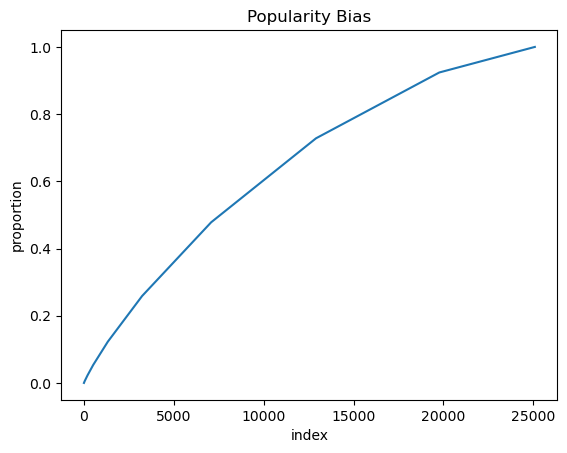

Топ-10 самых частотных рекомендаций:
shape: (10, 7)
┌────────────────┬───────┬──────────┬────────────────┬────────────────┬───────────┬────────────────┐
│ item_id        ┆ count ┆ brand_id ┆ category       ┆ subcategory    ┆ price     ┆ embedding      │
│ ---            ┆ ---   ┆ ---      ┆ ---            ┆ ---            ┆ ---       ┆ ---            │
│ str            ┆ i64   ┆ u64      ┆ str            ┆ str            ┆ f64       ┆ array[f32,     │
│                ┆       ┆          ┆                ┆                ┆           ┆ 300]           │
╞════════════════╪═══════╪══════════╪════════════════╪════════════════╪═══════════╪════════════════╡
│ nfmcg_28361982 ┆ 12    ┆ 141256   ┆ null           ┆ null           ┆ -2.223232 ┆ [-0.059484,    │
│                ┆       ┆          ┆                ┆                ┆           ┆ 0.104127, …    │
│                ┆       ┆          ┆                ┆                ┆           ┆ 0.0200…        │
│ nfmcg_1324509  ┆ 11    ┆ 38547    ┆ E

In [35]:
explore_recommendations(model_recommendations)

В следующей ячейке письменно ответьте на вопрос, когда может пригодиться "подмешивание случайных рекомендаций" в выдачу? Как бы вы реализовали подобное подмешивание (идейно и с точки зрения способа сэмплирования)? Какие ограничения есть у предложенного подхода?

*Это может пригодиться, чтобы пользователь видел не только однотипный контент, но и какие-то неожиданные находки, кроме того, это может помочь новым товарам - так у них будет шанс получить первые взаимодействия для дальнейшего развития их популярности. Вероятно, надо как-то перемешать предсказания основной модели и случайные товары, где в количестве сильно будет преобладать предсказание нашей модели, а случайные товары будут рандомно распределены среди этих предсказаний, но, наверно, лучше поближе к концу. Так или иначе будет снижение точности рекомендаций и риск оттока пользователей из-за менее релевантного контента.*

### TopPopular

Еще одна уже написанная моделька :)

Популярность айтема считается как суммарное количество положительных взаимодействий с ним. 

In [36]:
class TopPopularRecommender(BaseRecommender):
    def __init__(self):
        super().__init__(name = "toppop")
        self.popular_items = []
        self.inner_cutoff = 200  # чтобы не хранить больше, чем потеницально нужно

    def _fit(self, interactions: pl.DataFrame):
        self.popular_items = (
            interactions
            .group_by(self.item_col).agg(pl.col(self.interactions_col).sum())
            .sort(self.interactions_col, descending=True).head(self.inner_cutoff)
            [self.item_col].to_list()
        )

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        return [self.popular_items[:topn]] * len(user_ids)

In [37]:
model = TopPopularRecommender()

In [38]:
%%time
model.fit(train_val_events)

CPU times: total: 219 ms
Wall time: 44.6 ms


In [39]:
%%time
model_recommendations = model.recommend(test_users, topn = N)

CPU times: total: 0 ns
Wall time: 0 ns


In [40]:
test_events = test_events.with_columns(pl.Series(model_recommendations).alias(model.name))
RESULTS = pd.concat([
    RESULTS,
    pd.DataFrame(evaluate(test_events, recommendations_column = model.name), index = [model.name]),
])
RESULTS.style.format(precision = 5).background_gradient(cmap = "Blues")

,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.74005,1.00000,0.00196,1.00000,0.91828,1.00000,0.00260,1.00000,0.98673,1.00000,0.00293
random,0.00086,0.00009,0.00024,0.00554,0.00143,0.00012,0.00020,0.00850,0.00257,0.00022,0.00023,0.01079
toppop,0.12872,0.02293,0.04868,0.00000,0.20252,0.03618,0.04798,0.00000,0.44994,0.09973,0.07245,0.00001


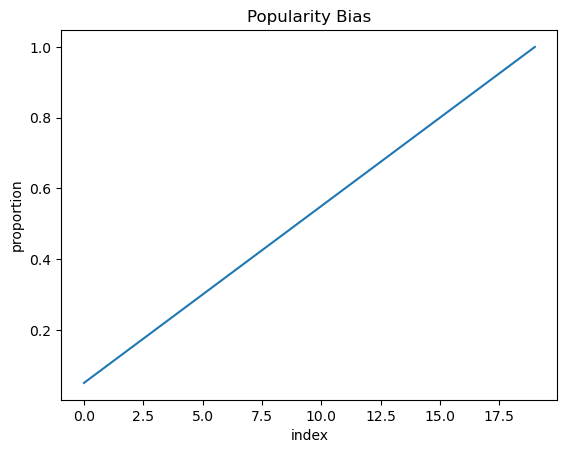

Топ-10 самых частотных рекомендаций:
shape: (10, 7)
┌────────────────┬───────┬──────────┬────────────────┬────────────────┬───────────┬────────────────┐
│ item_id        ┆ count ┆ brand_id ┆ category       ┆ subcategory    ┆ price     ┆ embedding      │
│ ---            ┆ ---   ┆ ---      ┆ ---            ┆ ---            ┆ ---       ┆ ---            │
│ str            ┆ i64   ┆ u64      ┆ str            ┆ str            ┆ f64       ┆ array[f32,     │
│                ┆       ┆          ┆                ┆                ┆           ┆ 300]           │
╞════════════════╪═══════╪══════════╪════════════════╪════════════════╪═══════════╪════════════════╡
│ nfmcg_8797298  ┆ 3496  ┆ 137356   ┆ Miscellaneous  ┆ null           ┆ 4.558963  ┆ [-0.098946,    │
│                ┆       ┆          ┆ Goods          ┆                ┆           ┆ 0.062027, …    │
│                ┆       ┆          ┆ (Uncategor…    ┆                ┆           ┆ 0.0670…        │
│ nfmcg_8957656  ┆ 3496  ┆ 80160    ┆ M

In [41]:
explore_recommendations(model_recommendations)

### SocdemTopPopular (1p)

А вот следующую модель вам придется реализовать самостоятельно. Идея в том, чтобы посчитать свой топ популярных айтемов для каждого соцдем-кластера пользователей (используйте `group_by`). Обратите внимание, что в случае, если на инференсе кластер не определен, нужно рекомендовать глобальный топ популярных айтемов, рассчитанный без учета кластеров.

Популярность айтема считается как суммарное количество положительных взаимодействий с ним.

In [42]:
class SocdemTopPopularRecommender(BaseRecommender):
    def __init__(self):
        super().__init__(name = "socdem_toppop")
        self.socdem_col = "socdem_cluster"
        self.socdem_popular_items_df = None
        self.popular_items = []
        self.inner_cutoff = 200  # чтобы не хранить больше, чем потеницально нужно

    def _fit(self, interactions: pl.DataFrame):
        interactions_with_socdem = interactions.join(
            USERS.select("user_id", self.socdem_col), 
            on = "user_id", 
            how = "left"
        )
        
        self.socdem_popular_items_df = (
            interactions_with_socdem
            .group_by([self.socdem_col, self.item_col])
            .agg(pl.col(self.interactions_col).sum().alias("popularity"))
            .sort([self.socdem_col, "popularity"], descending = [False, True])
            .group_by(self.socdem_col)
            .head(self.inner_cutoff)
        )
        
        self.popular_items = (
            interactions
            .group_by(self.item_col)
            .agg(pl.col(self.interactions_col).sum())
            .sort(self.interactions_col, descending = True)
            .head(self.inner_cutoff)
            [self.item_col]
            .to_list()
        )

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        global USERS 

        users_df = USERS.filter(pl.col("user_id").is_in(user_ids)).select("user_id", self.socdem_col)
        recommendations = []
        
        for user_id in user_ids:
            cluster = users_df.filter(pl.col("user_id") == user_id).select(self.socdem_col).item(0, 0) if user_id in users_df["user_id"].to_list() else None
            if cluster is not None:
                cluster_items = (
                    self.socdem_popular_items_df
                    .filter(pl.col(self.socdem_col) == cluster)
                    .select(self.item_col)
                    .to_series()
                    .to_list()
                )
                recommendations.append(cluster_items[:topn])
            else:
                recommendations.append(self.popular_items[:topn])
                
        return recommendations

In [43]:
model = SocdemTopPopularRecommender()

In [44]:
%%time
model.fit(train_val_events)

CPU times: total: 1.2 s
Wall time: 258 ms


In [45]:
%%time
model_recommendations = model.recommend(test_users, topn = N)

CPU times: total: 5.41 s
Wall time: 2.55 s


In [46]:
test_events = test_events.with_columns(pl.Series(model_recommendations).alias(model.name))
RESULTS = pd.concat([
    RESULTS,
    pd.DataFrame(evaluate(test_events, recommendations_column = model.name), index = [model.name]),
])
RESULTS.style.format(precision = 5).background_gradient(cmap = "Blues")

,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.74005,1.00000,0.00196,1.00000,0.91828,1.00000,0.00260,1.00000,0.98673,1.00000,0.00293
random,0.00086,0.00009,0.00024,0.00554,0.00143,0.00012,0.00020,0.00850,0.00257,0.00022,0.00023,0.01079
toppop,0.12872,0.02293,0.04868,0.00000,0.20252,0.03618,0.04798,0.00000,0.44994,0.09973,0.07245,0.00001
socdem_toppop,0.13844,0.02432,0.03489,0.00001,0.25973,0.05177,0.04386,0.00002,0.46482,0.10728,0.06431,0.00004


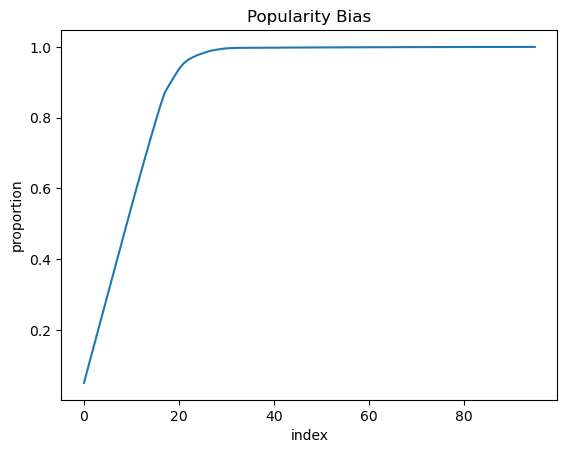

Топ-10 самых частотных рекомендаций:
shape: (10, 7)
┌────────────────┬───────┬──────────┬────────────────┬────────────────┬───────────┬────────────────┐
│ item_id        ┆ count ┆ brand_id ┆ category       ┆ subcategory    ┆ price     ┆ embedding      │
│ ---            ┆ ---   ┆ ---      ┆ ---            ┆ ---            ┆ ---       ┆ ---            │
│ str            ┆ i64   ┆ u64      ┆ str            ┆ str            ┆ f64       ┆ array[f32,     │
│                ┆       ┆          ┆                ┆                ┆           ┆ 300]           │
╞════════════════╪═══════╪══════════╪════════════════╪════════════════╪═══════════╪════════════════╡
│ nfmcg_7763862  ┆ 3493  ┆ 117885   ┆ Electronic     ┆ Portable Audio ┆ 2.405509  ┆ [-0.094552,    │
│                ┆       ┆          ┆ Devices and    ┆ Electronics    ┆           ┆ 0.068624, …    │
│                ┆       ┆          ┆ Gadgets        ┆                ┆           ┆ 0.0629…        │
│ nfmcg_12977198 ┆ 3491  ┆ 117885   ┆ E

In [47]:
explore_recommendations(model_recommendations)

## MF (3.5p)

In [48]:
class BaseMFRecommender(BaseRecommender):
    """
    Base class for matrix factorization recommenders.
    Adds user/item ID mapping and interaction matrix construction.
    """
    def __init__(self, name: str = ""):
        super().__init__(name=name)
        
        self.id2user = {}
        self.id2item = {}

        self.user2id = {}
        self.item2id = {}
        
        self.interactions_matrix: csr_matrix = None

    def _create_interaction_matrix(self, interactions: pl.DataFrame):
        """Create CSR interaction matrix and mappings. To be used in _fit() method"""
        unique_users = interactions[self.user_col].unique().to_list()
        unique_items = interactions[self.item_col].unique().to_list()
        
        self.id2user = dict(enumerate(unique_users))
        self.id2item = dict(enumerate(unique_items))
        self.user2id = {v: k for k, v in self.id2user.items()}
        self.item2id = {v: k for k, v in self.id2item.items()}
        
        rows = [self.user2id[user] for user in interactions[self.user_col]]
        cols = [self.item2id[item] for item in interactions[self.item_col]]
        
        self.interactions_matrix = csr_matrix(
            (interactions[self.interactions_col], (rows, cols)),
            shape = (len(unique_users), len(unique_items)),
            dtype = np.float32,  # лучше всегда указывать тип, чтобы не было проблем с памятью
        )

### Matrix operations (0.5p)

Простая задачка на вспомнить, как работать с матрицами. Реализуйте TopPopularRecommender как наследника класса BaseMFRecommender. Для расчетов популярных айтемов используйте матрицу интеракций вместо исходной polars-таблицы. Проверьте, что результаты совпадают с обычным TopPopularRecommender.

In [49]:
class TopPopularRecommender(BaseMFRecommender):
    def __init__(self):
        super().__init__(name = "toppop_mf")
        self.inner_cutoff = 200
        self.popular_items = []

    def _fit(self, interactions: pl.DataFrame):
        self._create_interaction_matrix(interactions)
        item_popularity = self.interactions_matrix.sum(axis = 0).A1
        top_indices = np.argsort(item_popularity)[::-1][:self.inner_cutoff]
        self.popular_items = [self.id2item[idx] for idx in top_indices]

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        return [self.popular_items[:topn]] * len(user_ids)

In [50]:
model = TopPopularRecommender()

In [51]:
%%time
model.fit(train_val_events)

CPU times: total: 1.47 s
Wall time: 1.27 s


In [52]:
%%time
model_recommendations = model.recommend(test_users, topn = N)

CPU times: total: 0 ns
Wall time: 2.34 ms


In [53]:
test_events = test_events.with_columns(pl.Series(model_recommendations).alias(model.name))
RESULTS = pd.concat([
    RESULTS,
    pd.DataFrame(evaluate(test_events, recommendations_column = model.name), index = [model.name]),
])
RESULTS.style.format(precision = 5).background_gradient(cmap = "Blues")

,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.74005,1.00000,0.00196,1.00000,0.91828,1.00000,0.00260,1.00000,0.98673,1.00000,0.00293
random,0.00086,0.00009,0.00024,0.00554,0.00143,0.00012,0.00020,0.00850,0.00257,0.00022,0.00023,0.01079
toppop,0.12872,0.02293,0.04868,0.00000,0.20252,0.03618,0.04798,0.00000,0.44994,0.09973,0.07245,0.00001
socdem_toppop,0.13844,0.02432,0.03489,0.00001,0.25973,0.05177,0.04386,0.00002,0.46482,0.10728,0.06431,0.00004
toppop_mf,0.12872,0.02293,0.04868,0.00000,0.20252,0.03618,0.04798,0.00000,0.44994,0.09973,0.07245,0.00001


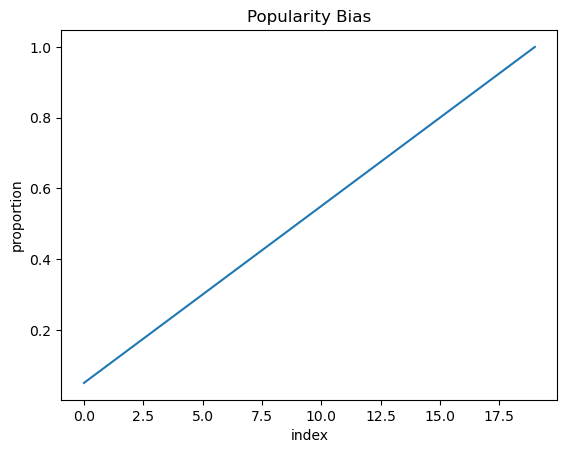

Топ-10 самых частотных рекомендаций:
shape: (10, 7)
┌────────────────┬───────┬──────────┬────────────────┬────────────────┬───────────┬────────────────┐
│ item_id        ┆ count ┆ brand_id ┆ category       ┆ subcategory    ┆ price     ┆ embedding      │
│ ---            ┆ ---   ┆ ---      ┆ ---            ┆ ---            ┆ ---       ┆ ---            │
│ str            ┆ i64   ┆ u64      ┆ str            ┆ str            ┆ f64       ┆ array[f32,     │
│                ┆       ┆          ┆                ┆                ┆           ┆ 300]           │
╞════════════════╪═══════╪══════════╪════════════════╪════════════════╪═══════════╪════════════════╡
│ nfmcg_8797298  ┆ 3496  ┆ 137356   ┆ Miscellaneous  ┆ null           ┆ 4.558963  ┆ [-0.098946,    │
│                ┆       ┆          ┆ Goods          ┆                ┆           ┆ 0.062027, …    │
│                ┆       ┆          ┆ (Uncategor…    ┆                ┆           ┆ 0.0670…        │
│ nfmcg_8957656  ┆ 3496  ┆ 80160    ┆ M

In [54]:
explore_recommendations(model_recommendations)

Здесь могло бы быть задание на реализацию SVD в качестве рекомедательной модели, но на практике она скорее не используется, поэтому - для желающих - остается на самостоятельное изучение :)

### iALS (1p)

А вот что используется на практике, так это модель iALS из библиотеки `implicit`. Реализуйте iALSRecommender(BaseMFRecommender) как обертку для данной модели. Обратите внимание, что модель из коробки умеет рекомендовать для батча пользователей.

In [55]:
class iALSRecommender(BaseMFRecommender):
    def __init__(self, name = "ials", factors = 64, regularization = 0.01, alpha = 40.0, iterations = 15):
        super().__init__(name = name)
        self.factors = factors
        self.regularization = regularization
        self.alpha = alpha
        self.iterations = iterations
        self.P = None
        self.Q = None
        
    def _fit(self, interactions: pl.DataFrame):
        self._create_interaction_matrix(interactions)
        
        n_users, n_items = self.interactions_matrix.shape
        
        R = self.interactions_matrix.toarray()
        
        self.P = np.random.normal(0, 0.1, (n_users, self.factors))
        self.Q = np.random.normal(0, 0.1, (n_items, self.factors))
        
        for i in range(self.iterations):
            print(f"Iteration {i+1}/{self.iterations}")
            self.P = self._als_step(R, self.P, self.Q)
            self.Q = self._als_step(R.T, self.Q, self.P)
            
    def _als_step(self, R, X, Y):
        n = R.shape[0]
        k = Y.shape[1]
        YtY = Y.T @ Y
        I = np.eye(k)
        
        X_new = X.copy()
        
        for u in range(n):
            idx = R[u] > 0
            if np.any(idx):
                Yu = Y[idx]
                A = YtY + (self.alpha - 1) * (Yu.T @ Yu) + self.regularization * I
                b = (1 + self.alpha) * Yu.sum(axis = 0)
                X_new[u] = np.linalg.solve(A, b)
                
        return X_new
    
    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        result = []
        
        for user_id in user_ids:
            if user_id in self.user2id:
                u = self.user2id[user_id]
                
                scores = self.P[u] @ self.Q.T
                
                mask = self.interactions_matrix[u].indices
                scores[mask] = -np.inf
                
                top_indices = np.argsort(scores)[-topn:][::-1]
                result.append([self.id2item[i] for i in top_indices])
            else:
                result.append([])
                
        return result

Подберите лучшие гиперпарметры `factors`, `regularization`, `alpha` на валидационной выборке. Замерьте не только метрики качества, но и время обучения и инференса моделей.

Обучите лучшую модель на train+val и сделайте предсказания для test так же, как с предыдущими моделями. 

In [56]:
param_grid = {
    'factors': [32, 64],
    'regularization': [0.001, 0.01],
    'alpha': [10.0, 40.0]
}

results = []

for factors, reg, alpha in product(param_grid['factors'], param_grid['regularization'], param_grid['alpha']):
    print(f"factors={factors}, reg={reg}, alpha={alpha}")
    
    model = iALSRecommender(factors = factors, regularization = reg, alpha = alpha, iterations = 10)
    model.fit(train_events)
    
    val_recs = model.recommend(val_users, topn = 20)
    val_events_with_recs = val_events.with_columns(pl.Series(val_recs).alias("preds"))
    metrics = evaluate(val_events_with_recs, "preds")
    
    results.append({
        'factors': factors, 'reg': reg, 'alpha': alpha,
        'hr@10': metrics['hit_rate@10'], 'recall@10': metrics['recall@10']
    })

results_df = pd.DataFrame(results).sort_values('hr@10', ascending = False)
best = results_df.iloc[0]
print("\nЛучшие параметры:")
print(results_df.head(1))

factors=32, reg=0.001, alpha=10.0
Iteration 1/10
Iteration 2/10
Iteration 3/10
Iteration 4/10
Iteration 5/10
Iteration 6/10
Iteration 7/10
Iteration 8/10
Iteration 9/10
Iteration 10/10
factors=32, reg=0.001, alpha=40.0
Iteration 1/10
Iteration 2/10
Iteration 3/10
Iteration 4/10
Iteration 5/10
Iteration 6/10
Iteration 7/10
Iteration 8/10
Iteration 9/10
Iteration 10/10
factors=32, reg=0.01, alpha=10.0
Iteration 1/10
Iteration 2/10
Iteration 3/10
Iteration 4/10
Iteration 5/10
Iteration 6/10
Iteration 7/10
Iteration 8/10
Iteration 9/10
Iteration 10/10
factors=32, reg=0.01, alpha=40.0
Iteration 1/10
Iteration 2/10
Iteration 3/10
Iteration 4/10
Iteration 5/10
Iteration 6/10
Iteration 7/10
Iteration 8/10
Iteration 9/10
Iteration 10/10
factors=64, reg=0.001, alpha=10.0
Iteration 1/10
Iteration 2/10
Iteration 3/10
Iteration 4/10
Iteration 5/10
Iteration 6/10
Iteration 7/10
Iteration 8/10
Iteration 9/10
Iteration 10/10
factors=64, reg=0.001, alpha=40.0
Iteration 1/10
Iteration 2/10
Iteration 3/1

In [57]:
model = iALSRecommender(
    factors = int(best['factors']),
    regularization = best['reg'],
    alpha = best['alpha'],
    iterations = 15
)

In [58]:
%%time
model.fit(train_val_events)

Iteration 1/15
Iteration 2/15
Iteration 3/15
Iteration 4/15
Iteration 5/15
Iteration 6/15
Iteration 7/15
Iteration 8/15
Iteration 9/15
Iteration 10/15
Iteration 11/15
Iteration 12/15
Iteration 13/15
Iteration 14/15
Iteration 15/15
CPU times: total: 2min 58s
Wall time: 3min


In [59]:
%%time
model_recommendations = model.recommend(test_users, topn = N)

CPU times: total: 16.6 s
Wall time: 10 s


In [60]:
test_events = test_events.with_columns(pl.Series(model_recommendations).alias(model.name))
RESULTS = pd.concat([
    RESULTS,
    pd.DataFrame(evaluate(test_events, recommendations_column = model.name), index = [model.name]),
])
RESULTS.style.format(precision = 5).background_gradient(cmap = "Blues")

,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.74005,1.00000,0.00196,1.00000,0.91828,1.00000,0.00260,1.00000,0.98673,1.00000,0.00293
random,0.00086,0.00009,0.00024,0.00554,0.00143,0.00012,0.00020,0.00850,0.00257,0.00022,0.00023,0.01079
toppop,0.12872,0.02293,0.04868,0.00000,0.20252,0.03618,0.04798,0.00000,0.44994,0.09973,0.07245,0.00001
socdem_toppop,0.13844,0.02432,0.03489,0.00001,0.25973,0.05177,0.04386,0.00002,0.46482,0.10728,0.06431,0.00004
toppop_mf,0.12872,0.02293,0.04868,0.00000,0.20252,0.03618,0.04798,0.00000,0.44994,0.09973,0.07245,0.00001
ials,0.09010,0.01556,0.02288,0.00014,0.13759,0.02540,0.02386,0.00020,0.21253,0.04083,0.02910,0.00028


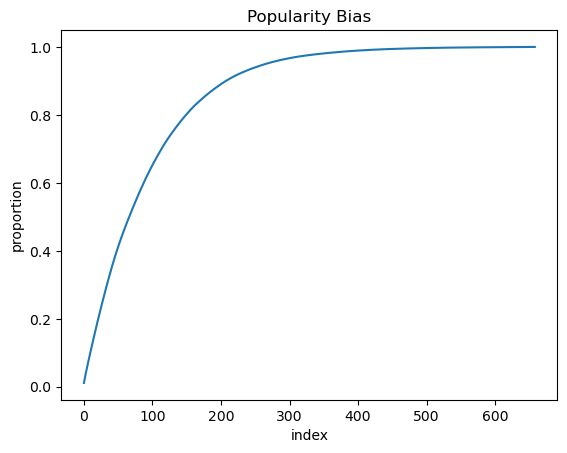

Топ-10 самых частотных рекомендаций:
shape: (10, 7)
┌────────────────┬───────┬──────────┬────────────────┬────────────────┬───────────┬────────────────┐
│ item_id        ┆ count ┆ brand_id ┆ category       ┆ subcategory    ┆ price     ┆ embedding      │
│ ---            ┆ ---   ┆ ---      ┆ ---            ┆ ---            ┆ ---       ┆ ---            │
│ str            ┆ i64   ┆ u64      ┆ str            ┆ str            ┆ f64       ┆ array[f32,     │
│                ┆       ┆          ┆                ┆                ┆           ┆ 300]           │
╞════════════════╪═══════╪══════════╪════════════════╪════════════════╪═══════════╪════════════════╡
│ nfmcg_25852582 ┆ 795   ┆ 194078   ┆ Children's     ┆ Children's     ┆ -0.230772 ┆ [-0.08969,     │
│                ┆       ┆          ┆ Products and   ┆ Games and Toys ┆           ┆ 0.051524, …    │
│                ┆       ┆          ┆ Childc…        ┆                ┆           ┆ -0.0142…       │
│ nfmcg_11650133 ┆ 762   ┆ 28667    ┆ E

In [61]:
explore_recommendations(model_recommendations)

## NeuMF (1.5p)

На основе материалов семинара реализуйте NeuMF. Оцените качество и сравните с остальными моделями.

Часть с обучением продублирована из кода семинара, вы можете изменять её, а также подобрать гиперпараметры. Попробуйте добиться сопоставимого с предыдущими моделями качества. Опишите сделанные изменения и результаты экспериментов.

In [85]:
unique_users = train_val_events["user_id"].unique()
unique_items = train_val_events["item_id"].unique()

id2user = dict(enumerate(unique_users))
id2item = dict(enumerate(unique_items))

user2id = {v: k for k, v in id2user.items()}
item2id = {v: k for k, v in id2item.items()}

In [86]:
print(len(unique_users), len(unique_items))

9610 27149


In [87]:
train_df = (
    train_val_events
    .filter(pl.col("label") > 0)
    .with_columns(
        user_id_encoded = pl.col("user_id").replace(user2id).cast(pl.Int32), 
        item_id_encoded = pl.col("item_id").replace(item2id).cast(pl.Int32)
    )
)

user_interactions = dict(
    train_df.group_by("user_id_encoded").agg(pl.col("item_id_encoded")).iter_rows()
)  # encoded_user_id: list[encoded_item_id]

In [88]:
train_encoded_users = torch.Tensor(train_df["user_id_encoded"]).long()
train_encoded_items = torch.Tensor(train_df["item_id_encoded"]).long()

In [89]:
class NeuMF(nn.Module):
    def __init__(
        self,
        n_users: int,
        m_items: int,
        n_factors: int,
        hidden_dim: int,
    ) -> None:
        super().__init__()
        self.name = "NeuMF"

        self.m_items = m_items

        # Embeddings for GMF
        self.user_emb_gmf = nn.Embedding(n_users, n_factors)
        self.item_emb_gmf = nn.Embedding(m_items, n_factors)

        # Embeddings for MLP
        self.user_emb_mlp = nn.Embedding(n_users, n_factors)
        self.item_emb_mlp = nn.Embedding(m_items, n_factors)

        # MLP tower
        self.mlp = nn.Sequential(
            nn.Linear(2 * n_factors, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
        )

        # Final prediction layer
        self.out = nn.Linear(
            n_factors + hidden_dim // 2, 1
        )

        self._init_weights()

    def _init_weights(self):
        for emb in [
            self.user_emb_gmf,
            self.item_emb_gmf,
            self.user_emb_mlp,
            self.item_emb_mlp,
        ]:
            nn.init.normal_(emb.weight, std = 0.01)

        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)

        nn.init.xavier_uniform_(self.out.weight)

    def forward(self, item: torch.Tensor, user: torch.Tensor) -> torch.Tensor:
        """
        item, user: LongTensor of shape (batch,)
        """

        # --- GMF part ---
        u_gmf = self.user_emb_gmf(user)      # (B, k)
        i_gmf = self.item_emb_gmf(item)      # (B, k)
        gmf = u_gmf * i_gmf                  # element-wise product

        # --- MLP part ---
        u_mlp = self.user_emb_mlp(user)      # (B, k)
        i_mlp = self.item_emb_mlp(item)      # (B, k)
        mlp_input = torch.cat([u_mlp, i_mlp], dim = -1)
        mlp_out = self.mlp(mlp_input)        # (B, hidden//2)

        # --- Fusion ---
        x = torch.cat([gmf, mlp_out], dim = -1)
        prediction = self.out(x).squeeze(-1)  # (B,)

        return prediction

In [95]:
model = NeuMF(n_users = len(unique_users), m_items = len(unique_items), n_factors = 32, hidden_dim = 128)
model

NeuMF(
  (user_emb_gmf): Embedding(9610, 32)
  (item_emb_gmf): Embedding(27149, 32)
  (user_emb_mlp): Embedding(9610, 32)
  (item_emb_mlp): Embedding(27149, 32)
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (out): Linear(in_features=96, out_features=1, bias=True)
)

In [96]:
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4)
loss_fn = nn.BCEWithLogitsLoss()

all_items = set(range(model.m_items))

In [97]:
num_epochs = 3
window_size = 100

for epoch in range(num_epochs):
    loss_window = deque(maxlen = window_size)
    
    pbar = tqdm(
        zip(train_encoded_users, train_encoded_items),
        total = len(train_encoded_users),
        desc = f"Epoch {epoch + 1}"
    )
    
    for user, item in pbar:
        optimizer.zero_grad()

        # negative sampling
        seen_items = set(user_interactions[user.item()])
        unseen_items = list(all_items - seen_items)
        neg_item = torch.tensor(
            np.random.choice(unseen_items),
            dtype=torch.long
        )

        # predictions
        pos_prediction = model(item.unsqueeze(0), user.unsqueeze(0))
        neg_prediction = model(neg_item.unsqueeze(0), user.unsqueeze(0))

        # targets
        pos_target = torch.ones_like(pos_prediction)
        neg_target = torch.zeros_like(neg_prediction)

        cur_loss = (
            loss_fn(pos_prediction, pos_target) 
            + loss_fn(neg_prediction, neg_target)
        )

        cur_loss.backward()
        optimizer.step()

        loss_window.append(cur_loss.item())
        avg_loss = np.mean(loss_window)

        pbar.set_postfix(loss = f"{avg_loss:.4f}")

Epoch 1:   0%|          | 0/57223 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/57223 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/57223 [00:00<?, ?it/s]

In [107]:
model.eval()

test_recs = []
all_items_list = list(range(model.m_items))
items_tensor = torch.tensor(all_items_list, dtype = torch.long)

for user_id in test_users:
    if user_id in user2id:
        u = user2id[user_id]
        users_tensor = torch.tensor([u] * len(all_items_list), dtype = torch.long)
        
        with torch.no_grad():
            scores = model(items_tensor, users_tensor).numpy()
        
        seen = set(user_interactions.get(u, []))
        for i in seen:
            scores[i] = -np.inf
        
        top_indices = np.argsort(scores)[-20:][::-1]
        test_recs.append([id2item[idx] for idx in top_indices])
    else:
        test_recs.append([])

test_events_neumf = test_events.with_columns(pl.Series(test_recs).alias("neumf"))
metrics = evaluate(test_events_neumf, "neumf")

RESULTS = pd.concat([RESULTS, pd.DataFrame(metrics, index = ["neumf"])])
RESULTS.style.format(precision = 5).background_gradient(cmap = "Blues")

,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.74005,1.00000,0.00196,1.00000,0.91828,1.00000,0.00260,1.00000,0.98673,1.00000,0.00293
random,0.00086,0.00009,0.00024,0.00554,0.00143,0.00012,0.00020,0.00850,0.00257,0.00022,0.00023,0.01079
toppop,0.12872,0.02293,0.04868,0.00000,0.20252,0.03618,0.04798,0.00000,0.44994,0.09973,0.07245,0.00001
socdem_toppop,0.13844,0.02432,0.03489,0.00001,0.25973,0.05177,0.04386,0.00002,0.46482,0.10728,0.06431,0.00004
toppop_mf,0.12872,0.02293,0.04868,0.00000,0.20252,0.03618,0.04798,0.00000,0.44994,0.09973,0.07245,0.00001
ials,0.09010,0.01556,0.02288,0.00014,0.13759,0.02540,0.02386,0.00020,0.21253,0.04083,0.02910,0.00028
neumf,0.12872,0.02274,0.02210,0.00000,0.30492,0.05722,0.03802,0.00001,0.47855,0.11245,0.05744,0.00001


*Сопоставимое качество получилось и на базовом решении в принципе, попробовал увеличить n_factors до 32 и hidden_dim до 128, что ещё увеличило время обучения модели. В итоговом варианте оставил оба этих изменения, по сравнению с базовым они дали прирост по hr и recall метрикам, однако понизили ndcg. Теперь модель neumf стала лидером по recall метрикам.*

## Results (0.5p)

Опишите результаты, полученные в данной работе. Достаточно показать итоговую таблицу с метриками и проинтерпретировать полученные значения. Жалобы/предложения также принимаются :)

Пример того, что может получиться. Это ок, если метрики бейзлайна окажутся лучше модельных метрик, но проинтерпретировать данный феномен всё равно необходимо.

In [118]:
RESULTS.style.format(precision = 5).background_gradient(cmap = "Blues")

,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.74005,1.00000,0.00196,1.00000,0.91828,1.00000,0.00260,1.00000,0.98673,1.00000,0.00293
random,0.00086,0.00009,0.00024,0.00554,0.00143,0.00012,0.00020,0.00850,0.00257,0.00022,0.00023,0.01079
toppop,0.12872,0.02293,0.04868,0.00000,0.20252,0.03618,0.04798,0.00000,0.44994,0.09973,0.07245,0.00001
socdem_toppop,0.13844,0.02432,0.03489,0.00001,0.25973,0.05177,0.04386,0.00002,0.46482,0.10728,0.06431,0.00004
toppop_mf,0.12872,0.02293,0.04868,0.00000,0.20252,0.03618,0.04798,0.00000,0.44994,0.09973,0.07245,0.00001
ials,0.09010,0.01556,0.02288,0.00014,0.13759,0.02540,0.02386,0.00020,0.21253,0.04083,0.02910,0.00028
neumf,0.12872,0.02274,0.02210,0.00000,0.30492,0.05722,0.03802,0.00001,0.47855,0.11245,0.05744,0.00001


*random ожидаемо показал худшую точность с максимальным покрытием товаров. toppop же естественно показал минимальное покрытие товаров, рекомендуя самые популярные, но при этом показал неплохую точность. Модели toppop и toppop_mf действительно получились одинаковыми как и предполагалось по заданию. socdem_toppop улучшил обычный toppop за счет персонализации по кластерам. iALS показал достаточно низкие результаты, уступив простым моделям, вероятно, из-за проблем в реализации или подборе гиперпараметров. neumf даже с небольшой настройкой достиг неплохих результатов, превзойдя другие подходы в hr и recall метриках, однако уступил в ndcg. Простые модели бейзлайна работают удивительно хорошо, сложные модели, вероятно, могут их превзойти, но потребуется тщательная настройка гиперпараметров и архитектуры в целом. По метрикам наблюдается классический trade-off между точностью и разнообразием рекомендаций.*